# Adversarial Search: MiniMax and Alpha-Beta Pruning

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement minimax and alpha–beta pruning for game trees
- Apply adversarial search to simple two‑player games

## 🔗 Where this fits

**Builds on:** Unit 1, lesson 08 "A* Search Algorithm" — the same game tree, now with a second player who is trying to beat you.

---


## 🎯 New York, 11 May 1997

Deep Blue beat Garry Kasparov **3½–2½** in a six-game rematch — the first time a
reigning world chess champion lost a match to a machine under tournament
conditions. IBM's machine evaluated on the order of **100–200 million positions
per second** on custom chess hardware. Kasparov had beaten the previous version a
year earlier; IBM more than doubled the chess chips and came back.

What is worth knowing for this notebook is *what Deep Blue was doing* with those
200 million positions a second. It was running the two algorithms you are about
to write: **minimax** — assume the opponent plays the best reply, and score each
of your moves by the worst thing that can then happen — and **alpha-beta
pruning**, which throws away branches that provably cannot change the decision.
No learning, no neural network, no training data. A search, a hand-written
evaluation function, and enough hardware to go deep.

### What goes wrong without adversarial search

Take the ordinary search of notebooks 06–08 into a game and it plans a beautiful
route to victory — a route that assumes the opponent stands still. Every move
after the first is then a surprise, because the plan was built on the assumption
that only you get to move. Minimax is the correction: it plans *against* a player
who is trying to make your plan fail.


# Adversarial Search: MiniMax and Alpha-Beta Pruning
## AIAT 111 - Introduction to AI

---

## 📚 Learning Objectives

This notebook demonstrates key concepts through hands-on examples.

By completing this notebook, you will:
- Understand adversarial search problems
- Implement the MiniMax algorithm
- Apply Alpha-Beta pruning for optimization
- Build a game-playing agent
- Analyze game trees and decision-making

---

## 🔗 Prerequisites

- ✅ Python 3.8+ installed
- ✅ Understanding of trees and recursion
- ✅ Basic game theory concepts

---

## Real-World Context

You are building an AI agent to play strategic games like Tic-Tac-Toe or Connect 4. The agent needs to make optimal moves by considering all possible future game states and opponent responses. This requires adversarial search algorithms like MiniMax.

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup
import numpy as np
from typing import List, Tuple, Optional
import copy

print("=" * 60)
print("Adversarial Search: MiniMax Algorithm")
print("=" * 60)
print("\n✅ Setup complete!")

Adversarial Search: MiniMax Algorithm

✅ Setup complete!


## 1. Understanding Adversarial Search

### Key Concepts:
- **Adversarial Search**: Search in competitive environments with opponents
- **Game Tree**: Tree of all possible game states
- **MiniMax**: Algorithm to find optimal move assuming optimal opponent
- **Alpha-Beta Pruning**: Optimization technique to reduce search space

### MiniMax Algorithm:
- **Max player**: Tries to maximize score
- **Min player**: Tries to minimize score
- **Recursive**: Evaluates all possible moves recursively
- **Optimal**: Finds best move assuming opponent plays optimally


In [2]:
# The game environment for adversarial search: Tic-Tac-Toe as an immutable state object
# with moves, terminal test, and a score. MiniMax needs exactly this interface to plan ahead.
# Simple Tic-Tac-Toe Game State
class TicTacToe:
    """Simple Tic-Tac-Toe game for MiniMax demonstration"""
    def __init__(self, board=None, current_player='X'):
        self.board = [row[:] for row in board] if board else [[' '] * 3 for _ in range(3)]
        self.current_player = current_player

    def print_board(self):
        """Print the current board state"""
        for row in self.board:
            print('|'.join(row))
            print('-' * 5)

    def winner(self):
        """Return 'X' or 'O' if someone has three in a line, else None"""
        lines = [row for row in self.board]
        lines += [[self.board[r][c] for r in range(3)] for c in range(3)]
        lines += [[self.board[i][i] for i in range(3)],
                  [self.board[i][2 - i] for i in range(3)]]
        for line in lines:
            if line[0] != ' ' and line[0] == line[1] == line[2]:
                return line[0]
        return None

    def is_terminal(self):
        """Game over: someone won, or no empty squares remain"""
        return self.winner() is not None or not self.get_moves()

    def get_score(self):
        """+1 if X won, -1 if O won, 0 otherwise (draw / not finished)"""
        w = self.winner()
        return 1 if w == 'X' else (-1 if w == 'O' else 0)

    def get_moves(self):
        """Get all possible moves"""
        return [(i, j) for i in range(3) for j in range(3) if self.board[i][j] == ' ']

    def make_move(self, move):
        """Return a NEW state with the move applied and the turn switched"""
        new = TicTacToe(self.board, 'O' if self.current_player == 'X' else 'X')
        i, j = move
        new.board[i][j] = self.current_player
        return new

# A mid-game position: X to move, one move away from winning on the diagonal
game = TicTacToe([['X', 'O', 'X'],
                  ['O', 'X', ' '],
                  [' ', ' ', 'O']], current_player='X')
print("Mid-game position (X to move):")
game.print_board()
print(f"\nPossible moves: {game.get_moves()}")
print(f"Terminal? {game.is_terminal()}   Score right now: {game.get_score()}")

Mid-game position (X to move):
X|O|X
-----
O|X| 
-----
 | |O
-----

Possible moves: [(1, 2), (2, 0), (2, 1)]
Terminal? False   Score right now: 0


## 2. MiniMax Algorithm Implementation

The MiniMax algorithm works by:
1. **Maximizing** player's score (tries to win)
2. **Minimizing** opponent's score (assumes opponent tries to win)
3. **Recursively** evaluating all possible moves
4. **Choosing** the move with best worst-case outcome


In [3]:
# Plain MiniMax: X assumes the opponent plays perfectly, so it scores each move by the
# WORST outcome the opponent can force. We also count explored states to compare with pruning later.
node_count = {'n': 0}

def minimax(game_state, depth, is_maximizing):
    """
    MiniMax: X maximizes the score, O minimizes it.
    Explores EVERY reachable game state (no pruning).
    """
    node_count['n'] += 1
    if game_state.is_terminal() or depth == 0:
        return game_state.get_score()

    if is_maximizing:
        best_score = float('-inf')
        for move in game_state.get_moves():
            score = minimax(game_state.make_move(move), depth - 1, False)
            best_score = max(best_score, score)
        return best_score
    else:
        best_score = float('inf')
        for move in game_state.get_moves():
            score = minimax(game_state.make_move(move), depth - 1, True)
            best_score = min(best_score, score)
        return best_score

# Ask MiniMax: what is X's best move in the mid-game position?
node_count['n'] = 0
move_scores = {}
for move in game.get_moves():
    move_scores[move] = minimax(game.make_move(move), depth=9, is_maximizing=False)

best_move = max(move_scores, key=move_scores.get)
print("Score of every move for X (+1 = X wins with perfect play):")
for move, score in move_scores.items():
    marker = "  <- best" if move == best_move else ""
    print(f"  {move}: {score:+d}{marker}")
print(f"\nBest move: {best_move} (completes the X diagonal)")
print(f"Game states explored: {node_count['n']}")
minimax_nodes = node_count['n']

Score of every move for X (+1 = X wins with perfect play):
  (1, 2): +0
  (2, 0): +1  <- best
  (2, 1): +0

Best move: (2, 0) (completes the X diagonal)
Game states explored: 11


## 3. Alpha-Beta Pruning

Alpha-Beta pruning optimizes MiniMax by:
- **Pruning**: Eliminating branches that won't affect final decision
- **Alpha**: Best value maximizer can achieve
- **Beta**: Best value minimizer can achieve
- **Efficiency**: Reduces search space significantly

### Benefits:
- Same optimal result as MiniMax
- Much faster (can search deeper)
- Essential for complex games


In [4]:
# Alpha-Beta pruning: identical answers to MiniMax, but branches that cannot change the
# decision are skipped — the trick that made computer chess feasible.
def minimax_alpha_beta(game_state, depth, alpha, beta, is_maximizing):
    """
    MiniMax with Alpha-Beta pruning: same answer, fewer explored states.
    alpha = best score the maximizer can already guarantee
    beta  = best score the minimizer can already guarantee
    When beta <= alpha the remaining siblings cannot change the result -> prune.
    """
    node_count['n'] += 1
    if game_state.is_terminal() or depth == 0:
        return game_state.get_score()

    if is_maximizing:
        best_score = float('-inf')
        for move in game_state.get_moves():
            score = minimax_alpha_beta(game_state.make_move(move), depth - 1, alpha, beta, False)
            best_score = max(best_score, score)
            alpha = max(alpha, best_score)
            if beta <= alpha:
                break  # beta cutoff — prune remaining branches
        return best_score
    else:
        best_score = float('inf')
        for move in game_state.get_moves():
            score = minimax_alpha_beta(game_state.make_move(move), depth - 1, alpha, beta, True)
            best_score = min(best_score, score)
            beta = min(beta, best_score)
            if beta <= alpha:
                break  # alpha cutoff — prune remaining branches
        return best_score

# Same question, same answer
ab_scores = {}
for move in game.get_moves():
    ab_scores[move] = minimax_alpha_beta(game.make_move(move), 9, float('-inf'), float('inf'), False)
ab_best = max(ab_scores, key=ab_scores.get)
print(f"Alpha-Beta best move: {ab_best} (same as plain MiniMax: {ab_best == best_move})")

# Where pruning really pays off: analyze the WHOLE game from an empty board.
# The classic result: with perfect play by both sides, Tic-Tac-Toe is a draw.
empty = TicTacToe()

node_count['n'] = 0
full_minimax = minimax(empty, 9, True)
plain_nodes = node_count['n']

node_count['n'] = 0
full_ab = minimax_alpha_beta(empty, 9, float('-inf'), float('inf'), True)
ab_nodes = node_count['n']

print(f"\nFull-game analysis from the empty board (score 0 = draw with perfect play):")
print(f"  Plain MiniMax : score {full_minimax}, {plain_nodes:,} states explored")
print(f"  Alpha-Beta    : score {full_ab}, {ab_nodes:,} states explored")
print(f"  -> identical answer, {plain_nodes / ab_nodes:.1f}x fewer states thanks to pruning")

Alpha-Beta best move: (2, 0) (same as plain MiniMax: True)



Full-game analysis from the empty board (score 0 = draw with perfect play):
  Plain MiniMax : score 0, 549,946 states explored
  Alpha-Beta    : score 0, 18,297 states explored
  -> identical answer, 30.1x fewer states thanks to pruning


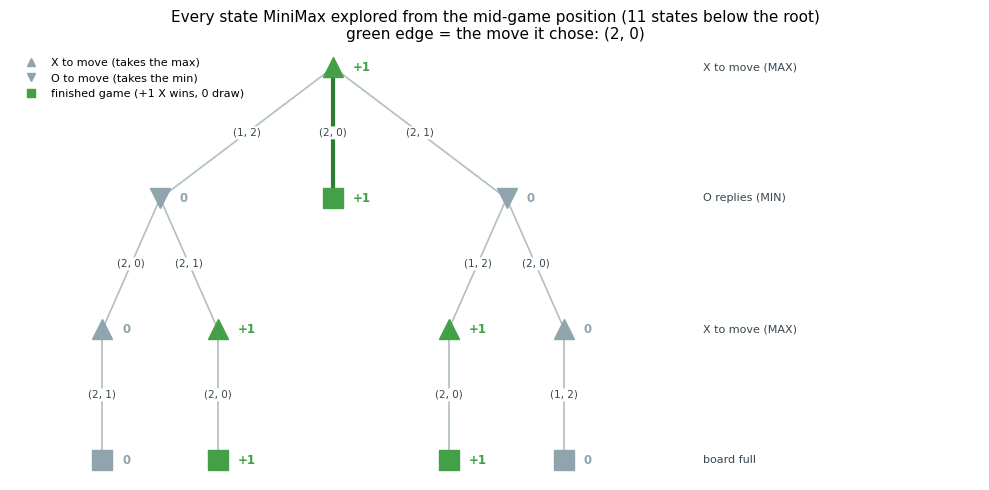

The three root moves, and why they score what they score:
  (1, 2) -> +0   (O has a reply that holds X to a draw)
  (2, 0) -> +1   (X completes the diagonal immediately)
  (2, 1) -> +0   (O has a reply that holds X to a draw)


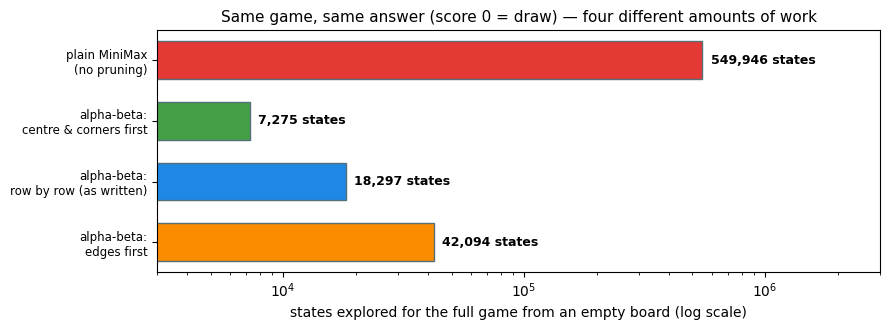


strategy                       states   score  vs plain MiniMax
plain MiniMax                 549,946       0  1.0x
alpha-beta, centre & corners first      7,275       0  75.6x fewer
alpha-beta, row by row (as written)     18,297       0  30.1x fewer
alpha-beta, edges first        42,094       0  13.1x fewer

Every run returned the same score. Only the amount of work changed —
by 5.8x between the best and worst ordering.


In [5]:
# ── Figure 1: the actual game tree MiniMax searched, with the values it backed up ──
# WHAT: rebuild the 11 states minimax explored from the mid-game position, ask the SAME
#       minimax() function for the value of each one, and draw them as a tree.
# WHY:  "score each move by the worst thing the opponent can then do" is a claim about a
#       tree. Printed as three numbers it is a fact to memorise; drawn, it is obvious.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

saved_count = node_count['n']          # keep the counters printed above untouched


def build_tree(state, is_maximizing):
    """Every reachable state below `state`, each labelled with its minimax value."""
    node = {'value': minimax(state, 9, is_maximizing),
            'maximizing': is_maximizing,
            'terminal': state.is_terminal(),
            'children': []}
    if not state.is_terminal():
        for move in state.get_moves():
            node['children'].append((move, build_tree(state.make_move(move), not is_maximizing)))
    return node


root = {'value': minimax(game, 9, True), 'maximizing': True, 'terminal': False,
        'children': [(move, build_tree(game.make_move(move), False))
                     for move in game.get_moves()]}
node_count['n'] = saved_count


def count_nodes(node):
    return 1 + sum(count_nodes(child) for _, child in node['children'])


# Honesty check: the drawing must contain exactly the states the cell above counted.
assert count_nodes(root) - 1 == minimax_nodes, "tree size does not match the printed count"
assert root['value'] == max(move_scores.values())

next_x = [0.0]


def layout(node, depth):
    """Leaves get evenly spaced columns; a parent sits above the middle of its children."""
    if not node['children']:
        node['x'] = next_x[0]
        next_x[0] += 1.0
    else:
        for _, child in node['children']:
            layout(child, depth + 1)
        node['x'] = sum(child['x'] for _, child in node['children']) / len(node['children'])
    node['y'] = -depth


layout(root, 0)
VALUE_COLOUR = {1: '#43a047', 0: '#90a4ae', -1: '#e53935'}

fig, ax = plt.subplots(figsize=(10, 5.0))


def draw(node, best_move=None):
    for move, child in node['children']:
        winning = (node is root and move == best_move)
        ax.plot([node['x'], child['x']], [node['y'], child['y']],
                color='#2e7d32' if winning else '#b0bec5',
                lw=3.0 if winning else 1.2, zorder=1)
        ax.text((node['x'] + child['x']) / 2, (node['y'] + child['y']) / 2, f"{move}",
                fontsize=7.5, color='#37474f', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.14', fc='white', ec='none'))
        draw(child, best_move)
    marker = 's' if node['terminal'] else ('^' if node['maximizing'] else 'v')
    ax.plot(node['x'], node['y'], marker=marker, markersize=14,
            color=VALUE_COLOUR[node['value']], zorder=3)
    shown = f"{node['value']:+d}" if node['value'] else "0"      # a draw is just 0
    ax.text(node['x'] + 0.17, node['y'], shown, fontsize=8.5,
            va='center', color=VALUE_COLOUR[node['value']], fontweight='bold', zorder=4)


draw(root, best_move=best_move)
for depth, label in enumerate(['X to move (MAX)', 'O replies (MIN)',
                              'X to move (MAX)', 'board full']):
    ax.text(next_x[0] + 0.2, -depth, label, fontsize=8, ha='left', va='center', color='#37474f')
ax.set_xlim(-0.8, next_x[0] + 2.6)
ax.set_axis_off()
ax.set_title(f"Every state MiniMax explored from the mid-game position "
             f"({minimax_nodes} states below the root)\n"
             f"green edge = the move it chose: {best_move}", fontsize=11)
ax.legend(handles=[Line2D([], [], marker='^', linestyle='', color='#90a4ae', label='X to move (takes the max)'),
                   Line2D([], [], marker='v', linestyle='', color='#90a4ae', label='O to move (takes the min)'),
                   Line2D([], [], marker='s', linestyle='', color='#43a047', label='finished game (+1 X wins, 0 draw)')],
          loc='upper left', fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

print("The three root moves, and why they score what they score:")
for move, score in move_scores.items():
    note = "X completes the diagonal immediately" if score == 1 else "O has a reply that holds X to a draw"
    print(f"  {move} -> {score:+d}   ({note})")

# ── Figure 2: pruning is real, and its size depends on the order of the moves ──
# WHAT: run alpha-beta over the WHOLE game four times, changing only the order in which
#       moves are tried, and count the states each run explored.
# WHY:  the 30x saving printed above is not a property of alpha-beta. It is a property
#       of alpha-beta PLUS an ordering, and this is the cheapest way to see that.
CENTRE, CORNERS = (1, 1), {(0, 0), (0, 2), (2, 0), (2, 2)}


def ab_ordered(state, depth, alpha, beta, is_maximizing, order, counter):
    """Identical to minimax_alpha_beta() above, except the move order is a parameter."""
    counter[0] += 1
    if state.is_terminal() or depth == 0:
        return state.get_score()
    moves = order(state.get_moves())
    if is_maximizing:
        best = float('-inf')
        for move in moves:
            best = max(best, ab_ordered(state.make_move(move), depth - 1, alpha, beta, False, order, counter))
            alpha = max(alpha, best)
            if beta <= alpha:
                break
        return best
    best = float('inf')
    for move in moves:
        best = min(best, ab_ordered(state.make_move(move), depth - 1, alpha, beta, True, order, counter))
        beta = min(beta, best)
        if beta <= alpha:
            break
    return best


orderings = [
    ("centre & corners first", lambda ms: sorted(ms, key=lambda m: (0 if m == CENTRE else (1 if m in CORNERS else 2), m))),
    ("row by row (as written)", lambda ms: ms),
    ("edges first", lambda ms: sorted(ms, key=lambda m: (0 if (m != CENTRE and m not in CORNERS) else (1 if m in CORNERS else 2), m))),
]
results = []
for name, order in orderings:
    counter = [0]
    score = ab_ordered(TicTacToe(), 9, float('-inf'), float('inf'), True, order, counter)
    results.append((name, counter[0], score))

# Honesty check: the "as written" ordering must reproduce the count printed above.
assert dict((n, c) for n, c, _ in results)["row by row (as written)"] == ab_nodes

labels = ['plain MiniMax\n(no pruning)'] + [f"alpha-beta:\n{n}" for n, _, _ in results]
counts = [plain_nodes] + [c for _, c, _ in results]
colours = ['#e53935', '#43a047', '#1e88e5', '#fb8c00']

fig2, ax2 = plt.subplots(figsize=(9, 3.4))
bars = ax2.barh(range(len(counts)), counts, color=colours, edgecolor='#546e7a', height=0.62)
for y, value in enumerate(counts):
    ax2.text(value * 1.08, y, f"{value:,} states", va='center', fontsize=9, fontweight='bold')
ax2.set_xscale('log')
ax2.set_xlim(3_000, 3_000_000)
ax2.set_yticks(range(len(labels)))
ax2.set_yticklabels(labels, fontsize=8.5)
ax2.invert_yaxis()
ax2.set_xlabel('states explored for the full game from an empty board (log scale)')
ax2.set_title('Same game, same answer (score 0 = draw) — four different amounts of work', fontsize=11)
fig2.tight_layout()
plt.show()

print(f"\n{'strategy':<26} {'states':>10}  {'score':>6}  vs plain MiniMax")
print(f"{'plain MiniMax':<26} {plain_nodes:>10,}  {full_minimax:>6}  1.0x")
for name, count, score in results:
    print(f"{'alpha-beta, ' + name:<26} {count:>10,}  {score:>6}  {plain_nodes / count:.1f}x fewer")
print("\nEvery run returned the same score. Only the amount of work changed —")
print(f"by {max(c for _, c, _ in results) / min(c for _, c, _ in results):.1f}x between the best and worst ordering.")


### 👁️ Read the tree, then read the bars

**Figure 1** is not a diagram of minimax in general — it is the exact set of states the
cell above explored, one node per state, with the value `minimax()` returned printed
next to it. Triangles pointing up are positions where X chooses (and takes the
maximum); triangles pointing down are O's turn (and O takes the minimum); squares are
finished games. The green edge is the move the algorithm played.

- **The winning move is the short branch.** `(2, 0)` ends the game immediately at +1 —
  one square node, no opponent reply to consider. The algorithm did not need depth
  there; it needed depth on the other two.
- **The other two moves die at the ▼ nodes.** Follow `(1, 2)`: one of its two
  continuations is +1 for X, the other is 0 — and because O picks the **minimum**, the
  branch is worth 0, not +1. That single arithmetic step is the entire idea of
  adversarial search: your good outcomes do not count if the opponent can avoid them.
- **A tie at the top is a real result.** Two of the three moves score 0. Minimax says
  they draw against perfect play; only `(2, 0)` wins.

**Figure 2** runs alpha-beta over the whole game four times and changes only *the order
in which moves are tried*. The answer is 0 — a draw — every single time. The work is
not the same at all: the printed table gives the exact counts, and the spread between
the best and worst ordering is several times over. Note what this does and does not
say: **alpha-beta never changes the answer, and the "30× saving" is not a property of
alpha-beta — it is a property of alpha-beta plus a move ordering.** Trying strong moves
first (centre and corners, in tic-tac-toe) prunes far more than trying weak ones first.
This is why real chess engines spend serious engineering effort on move ordering, and
why a pruning factor quoted without its ordering is not a number you can use.


## 📊 What the two runs actually proved

Both algorithms were asked the same two questions and printed their answers above:

| | best move from the mid-game position | full game from empty board | states explored |
|---|---|---|---|
| Plain MiniMax | (2, 0) | score 0 (draw) | **549,946** |
| Alpha-Beta | (2, 0) — identical | score 0 (draw) — identical | **18,297** |

**The conclusion these numbers support:** pruning changed *nothing* about the
answer and removed **97%** of the work — a **30.1×** reduction. That is the
result to remember, because it is what made deep game search practical at all:
Deep Blue's hardware bought positions per second, but alpha-beta is what decided
how many of those positions were worth looking at.

**The conclusion these numbers do not support:** that 30× is a constant. The
saving depends entirely on move ordering — search the best move first and
alpha-beta approaches the square root of the plain tree; search the worst first
and the saving collapses, in the theoretical worst case to nothing at all. The
figure above measures exactly this on our own board: **7,275** states when centre
and corners are tried first, **18,297** row by row, **42,094** when edges go first.
Real engines spend serious effort on move ordering for exactly this reason.

Also note what the full-board run tells you about the *game*: from an empty board
with both sides perfect, tic-tac-toe scores 0. It is a draw. Nine squares were
enough to prove it; the next section is about what happens when the board is bigger.


## 💬 Discuss

1. Minimax assumes the opponent plays **perfectly**. Against a beginner that
   assumption makes your agent play too safely — it defends against threats the
   opponent will never find. Is modelling a weaker opponent cheating, good
   product design, or both? What would you do in a chess app for children?
2. Deep Blue searched 200 million positions per second and had no idea what a
   pawn structure *meant*; AlphaGo, twenty years later, learned an evaluation
   from data. **For a business decision-support tool — say, pricing against a
   competitor — which of the two approaches would you trust, and what would you
   need to see before you trusted the other?**
3. Tic-tac-toe is zero-sum: your gain is exactly my loss. Name a real competitive
   situation in your region that is *not* zero-sum, and say what minimax would get
   wrong if you modelled it that way anyway.


## 4. Real-World Applications

### Game AI:
- **Chess**: Deep Blue, Stockfish use MiniMax variants
- **Checkers**: Perfect play achieved
- **Go**: AlphaGo uses advanced search + neural networks
- **Video Games**: Strategy game AI

### Decision Making:
- **Business**: Competitive strategy planning
- **Military**: Tactical decision support
- **Economics**: Game theory applications

### Limitations:
- **Combinatorial Explosion**: Too many states for complex games
- **Heuristic Evaluation**: Need good evaluation functions
- **Computational Cost**: Can be expensive for deep searches

---

## Summary

MiniMax and Alpha-Beta pruning are fundamental algorithms for:
- Game-playing AI
- Adversarial decision-making
- Optimal strategy finding

These algorithms demonstrate how AI can reason about competitive scenarios and make optimal decisions under uncertainty.


## ⚠️ Where this breaks

Minimax is exact, complete, and almost never runnable as written.

- **The tree explodes.** Nine squares cost 549,946 states. Claude Shannon's 1950
  paper (reference 1) put the chess game tree at roughly 10^120 positions. No
  hardware closes that gap — which is why every real engine **cuts off at a fixed
  depth and calls a hand-written or learned evaluation function** on a non-terminal
  position. The moment you do that, "optimal play" becomes "optimal with respect
  to my evaluation function", and the quality of the agent is the quality of that
  function, not of the search.
- **Alpha-beta's saving depends on move ordering.** Our 30.1× came from the order
  the moves happen to be generated in — row by row. Reorder them and the factor
  moves between roughly 13× and 76× on this same nine-square game, as the measured
  bars above show. (Simply *reversing* the list is not enough: on a board this
  symmetric it explores exactly the same 18,297 states. What matters is whether
  strong moves are tried first.) Any benchmark that quotes a pruning factor without
  stating the move ordering is quoting an accident.
- **It assumes perfect information.** Both players see the whole board here.
  Poker, most card games, sealed-bid auctions and real negotiations hide state,
  and minimax has nothing to say about them. **Use instead:** counterfactual
  regret minimisation and related methods — the approach behind the poker systems
  that beat professionals at heads-up no-limit hold'em in 2017.
- **It assumes a single number scores the outcome.** `get_score()` returns +1/0/-1.
  Real competitive decisions trade off revenue, reputation, staff time and risk,
  and collapsing those into one utility is the same political-decision-in-disguise
  you met in notebook 04.
- **It assumes the opponent is rational and adversarial.** Against an opponent who
  is careless, or who has a different objective entirely, minimax's "worst case"
  is not the case that happens — you have optimised for a fight nobody is having.
- **Cheaper alternative when the tree is too big and you have no good evaluation
  function:** Monte Carlo tree search — sample random playouts instead of
  enumerating, which is what made computer Go possible before neural networks.


## 📚 References

1. Shannon, C. E. (1950). *Programming a Computer for Playing Chess*. Philosophical Magazine, 41(314), 256–275.
2. Knuth, D. E., & Moore, R. W. (1975). *An Analysis of Alpha-Beta Pruning*. Artificial Intelligence, 6(4), 293–326.
3. Silver, D., Huang, A., Maddison, C. J., et al. (2016). *Mastering the game of Go with deep neural networks and tree search*. Nature, 529, 484–489.
4. Schrittwieser, J., Antonoglou, I., Hubert, T., et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature, 588, 604–609. <https://arxiv.org/abs/1911.08265>
5. Schultz, J., Adamek, J., Jusup, M., et al. (2024). *Mastering Board Games by External and Internal Planning with Language Models*. arXiv. <https://arxiv.org/abs/2412.12119>
6. DeepSeek-AI (2025). *DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning*. arXiv. <https://arxiv.org/abs/2501.12948>